In [1]:
from os import environ
from pathlib import Path
from tempfile import TemporaryDirectory
from urllib.request import urlretrieve

import numpy as np
import pandas as pd

import scarf
from scarf.plotting import CellField, StudyDesign

scarf.configure_output(level="WARNING", progress=False)

DATA_URL = (
    "https://datasets.cellxgene.cziscience.com/"
    "3b751975-34bb-409a-a9b7-98380f0450ea.h5ad"
)
dataset_directory = Path(environ.get("SCARF_DOCS_DATA_DIR", "scarf_datasets"))
dataset_directory.mkdir(parents=True, exist_ok=True)
h5ad_path = dataset_directory / "binvignat_ra_pbmc.h5ad"
source_store = dataset_directory / "binvignat_ra_pbmc.zarr"

if not h5ad_path.exists():
    partial_path = h5ad_path.with_suffix(".h5ad.part")
    urlretrieve(DATA_URL, partial_path)
    partial_path.replace(h5ad_path)

inspection = scarf.inspect_h5ad(str(h5ad_path))
assert inspection.matrixKey == "raw/X"
assert {"raw/X", "X"}.issubset(inspection.matrixCandidates)
assert inspection.integerLike is True
assert (inspection.nCells, inspection.nFeatures) == (108_717, 21_648)
{
    "matrix": inspection.matrixKey,
    "encoding": inspection.matrixEncoding,
    "integer-like": inspection.integerLike,
    "shape": (inspection.nCells, inspection.nFeatures),
}

{'matrix': 'raw/X',
 'encoding': 'csr',
 'integer-like': True,
 'shape': (108717, 21648)}

In [2]:
if not source_store.exists():
    with TemporaryDirectory(dir=dataset_directory) as conversion_directory:
        staged_store = Path(conversion_directory) / source_store.name
        reader = scarf.H5adReader.from_inspect(inspection)
        try:
            scarf.H5adToZarr(
                reader,
                zarr_loc=str(staged_store),
                assay_name="RNA",
                nthreads=4,
            ).dump()
        finally:
            reader.h5.close()
        staged_store.replace(source_store)

In [3]:
source = scarf.DataStore(
    str(source_store),
    default_assay="RNA",
    min_features_per_cell=0,
    nthreads=4,
)
assert source.cells.N == 108_717

analysis_directory = TemporaryDirectory()
ds = scarf.mount_datastore(
    str(source_store),
    at=str(Path(analysis_directory.name) / "condition_analysis.zarr"),
    default_assay="RNA",
    min_features_per_cell=0,
    nthreads=4,
)

In [4]:
GROUPS = ["normal", "rheumatoid arthritis"]

fine_annotation = np.asarray(ds.cells.fetch_all("fine_annot"), dtype=object)
pair_index = np.asarray(
    ds.cells.fetch_all("pair_index_CW"),
    dtype=np.float64,
)
matched_gamma_delta = np.isfinite(pair_index) & (
    fine_annotation == "yd T cells"
)

ds.cells.insert(
    "matched_yd_t_cells",
    matched_gamma_delta,
    overwrite=True,
)
cells = ds.snapshot_cell_selection("matched_yd_t_cells")

In [5]:
donor_id = np.asarray(ds.cells.fetch_all("donor_id"), dtype=object)
disease = np.asarray(ds.cells.fetch_all("disease"), dtype=object)

donor_design = pd.DataFrame(
    {
        "donor_id": donor_id[matched_gamma_delta],
        "disease": disease[matched_gamma_delta],
        "pair_index_CW": pair_index[matched_gamma_delta],
    }
).drop_duplicates()

assert int(matched_gamma_delta.sum()) == 1_386
assert len(donor_design) == 36
assert donor_design["donor_id"].nunique() == 36
assert donor_design["pair_index_CW"].nunique() == 18
assert set(donor_design["disease"]) == set(GROUPS)

pair_balance = donor_design.groupby(
    "pair_index_CW",
    observed=True,
).agg(
    donors=("donor_id", "nunique"),
    conditions=("disease", "nunique"),
)
assert pair_balance["donors"].eq(2).all()
assert pair_balance["conditions"].eq(2).all()

print(
    {
        "cells": int(matched_gamma_delta.sum()),
        "donors": donor_design["donor_id"].nunique(),
        "matched_pairs": donor_design["pair_index_CW"].nunique(),
    }
)

{'cells': 1386, 'donors': 36, 'matched_pairs': 18}


In [6]:
panel = ["IFNG", "IFIT2", "TNF", "GZMA", "ISG15", "S100A4"]
condition = CellField("disease")

paired_result = ds.run_statistical_testing(
    panel,
    condition,
    cell_selection=cells,
    groups=GROUPS,
    test="wilcoxon",
    sample_by="donor_id",
    pair_by="pair_index_CW",
    sample_stat="mean",
    adjustment="fdr_bh",
)

panel_table = pd.concat(
    {gene: paired_result.tables[gene] for gene in panel},
    names=["gene"],
).reset_index(level="gene")
panel_table = panel_table[
    [
        "gene",
        "group_1",
        "group_2",
        "n_pairs",
        "statistic",
        "p_value",
        "p_value_adjusted",
    ]
]

assert panel_table["n_pairs"].eq(18).all()
assert panel_table["p_value_adjusted"].notna().all()
assert not panel_table["p_value_adjusted"].le(0.05).any()
panel_table

,gene,group_1,group_2,n_pairs,statistic,p_value,p_value_adjusted
0,IFNG,normal,rheumatoid arthritis,18,39.0,1.000000,1.0000
0,IFIT2,normal,rheumatoid arthritis,18,26.0,0.878482,1.0000
0,TNF,normal,rheumatoid arthritis,18,57.0,0.864705,1.0000
0,GZMA,normal,rheumatoid arthritis,18,63.0,0.346550,0.6931
0,ISG15,normal,rheumatoid arthritis,18,13.0,0.139414,0.6931
0,S100A4,normal,rheumatoid arthritis,18,35.0,0.271948,0.6931


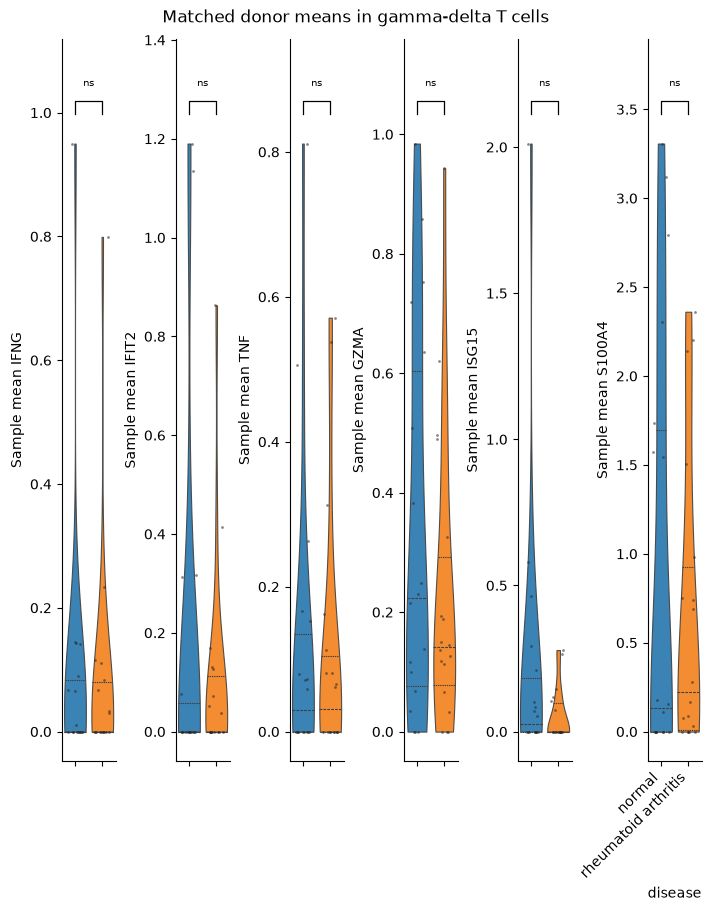

In [7]:
plot_design = StudyDesign(
    sample_by="donor_id",
    condition_by="disease",
    pair_by="pair_index_CW",
)

ds.plots.distribution(
    panel,
    grouping=condition,
    cell_selection=cells,
    groups=GROUPS,
    study_design=plot_design,
    sample_stat="mean",
    kind="stacked_violin",
    share_y=False,
    max_points=100,
    point_size=2.0,
    point_alpha=0.55,
    stats_results=paired_result,
    stats_show_p=False,
    figsize=(7.0, 9.0),
    title="Matched donor means in gamma-delta T cells",
)